## **PRESENTACIÓN:**

El presente modelo va a aprender a clasificar tumores como **malignos** o **benignos** usando el dataset Breast Cancer Wisconsin que viene con sklearn o desde el archivo (data_cancer.csv), uno de los datasets más clásicos en Machine Learning. 

Este es exactamente el tipo de problema que los sistemas de IA ayudan a resolver en hospitales reales.

Viene incluido directamente en scikit-learn, así que no necesitas descargar nada.

**Desmarcar (descomentar) las siguientes líneas si no desea utilizar el archivo CSV**
    #from sklearn.datasets import load_breast_cancer
    #cancer = load_breast_cancer()
    #X = pd.DataFrame(cancer.data, columns=cancer.feature_names)

**Marca (comentar) las siguientes líneas si desea usar el dataset que viene con la libreria sklearn**
    cancer=pd.read_csv("data_cancer.csv")
    X = pd.DataFrame(cancer)

    El modelo recibirá 30 características médicas de un tumor (tamaño, textura, forma...) y predecirá si es maligno (peligroso) o benigno (no peligroso). 

**Convertir sklearn cancer dataset a archivo CSV**
    df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    df['target'] = pd.Series(cancer.target)
    df.to_csv("data_cancer.csv")

Dataset: 569 pacientes, 32 características
✅ Modelo entrenado
🎯 Precisión: 100.00%
              precision    recall  f1-score   support

     Maligno       1.00      1.00      1.00        42
     Benigno       1.00      1.00      1.00        72

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



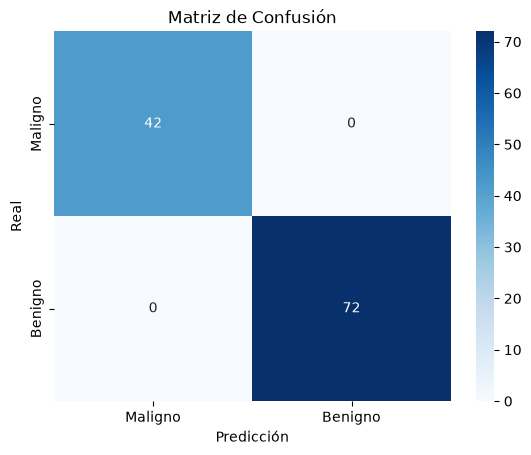


🔮 Predicción: BENIGNO ✅
📊 Confianza: 100.0%
💾 Modelo guardado exitosamente


In [10]:
# ============================================
# IMPORTANDO LIBRERIAS NECESARIAS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

#from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. CARGAR DATOS
#cancer = load_breast_cancer()

cancer=pd.read_csv("data_cancer.csv")

#X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
X = pd.DataFrame(cancer)

y = pd.Series(cancer.target)
print(f"Dataset: {X.shape[0]} pacientes, {X.shape[1]} características")

# 2. DIVIDIR EN ENTRENAMIENTO Y PRUEBA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. NORMALIZAR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. ENTRENAR EL MODELO
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train_scaled, y_train)
print("✅ Modelo entrenado")

# 5. EVALUAR
y_pred    = modelo.predict(X_test_scaled)
precision = accuracy_score(y_test, y_pred)
print(f"🎯 Precisión: {precision*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=['Maligno','Benigno']))

# 6. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Maligno','Benigno'],
            yticklabels=['Maligno','Benigno'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

# 7. PREDICCIÓN CON NUEVO DATO
nuevo = scaler.transform(X_test.iloc[6:7])
pred  = modelo.predict(nuevo)
prob  = modelo.predict_proba(nuevo)
print(f"\n🔮 Predicción: {'BENIGNO ✅' if pred[0]==1 else 'MALIGNO ⚠️'}")
print(f"📊 Confianza: {max(prob[0])*100:.1f}%")

# 8. GUARDAR
joblib.dump(modelo, 'modelo_cancer.pkl')
joblib.dump(scaler, 'scaler_cancer.pkl')
print("💾 Modelo guardado exitosamente")